# Quickstart Notebook

This notebook loads a CSV dataset using the shared dataloader utilities.

In [3]:
from pathlib import Path
import sys

# Ensure project root is on sys.path for imports
project_root = Path.cwd()
while not (project_root / "main.py").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_illness_data

df = load_illness_data("SCZ", in_notebook=True, distribution="low", p_value=0.0001)

Loading data for illness SCZ at ../../data/sampled/low/sampled_SCZ_p0.0001.txt
Starting to load ../../data/sampled/low/sampled_SCZ_p0.0001.txt with pandas...


Loading sampled_SCZ_p0.0001.txt:  88%|████████▊ | 15.7M/17.9M [00:00<00:00, 24.9MB/s]


In [4]:
# convert the Z_score column to binary labels based on a threshold at 0
df["Z"] = (df["Z"] > 0).astype(int)

In [32]:
# print relative balance of classes
print("Class distribution:")
print(df["Z"].value_counts(normalize=True))

Class distribution:
Z
1    0.574961
0    0.425039
Name: proportion, dtype: float64


In [5]:
df.head(5)

,ID,Z,Area_BA1_left,Area_BA1_right,Area_BA2_left,Area_BA2_right,Area_BA3a_left,Area_BA3a_right,Area_BA3b_left,Area_BA3b_right,...,Volume_superiorparietal_left,Volume_superiorparietal_right,Volume_superiortemporal_left,Volume_superiortemporal_right,Volume_supramarginal_left,Volume_supramarginal_right,Volume_transversetemporal_left,Volume_transversetemporal_right,Volume_vessel_left,Volume_vessel_right
0,rs13195636,0,-1.489400,-0.387185,-0.196650,-0.133390,-1.10115,0.081905,-0.056685,-0.393875,...,1.317550,1.22442,0.548906,1.256920,2.31216,2.81772,1.290840,1.017650,0.438936,0.888946
1,rs2232429,0,-1.301130,-0.418471,-0.027041,0.089050,-1.34682,0.097538,-0.113067,-0.621313,...,1.376480,1.40299,0.591983,1.791440,2.40117,3.76148,2.058150,1.617520,0.630818,0.672325
2,rs9257566,0,-0.764395,-0.169134,0.373753,-0.287440,-1.49126,-0.453089,-0.331564,-0.792425,...,0.415352,1.01528,-0.344105,0.921726,1.46870,2.84155,0.889168,0.720042,0.468549,1.061840
3,rs13195401,0,-1.497470,0.003458,-1.012180,-0.182537,-1.23992,-0.017051,-0.099354,-0.204873,...,1.783740,1.23664,0.684052,1.316600,2.94842,3.05688,1.507120,1.202600,0.167476,0.909807
4,rs66975207,0,-1.774430,-0.206796,-0.984195,-0.474553,-1.37791,-0.210942,-0.248291,-0.409737,...,1.680310,1.15361,0.699188,1.401990,2.86193,2.97076,1.565520,1.094290,0.144467,0.947757


In [6]:
from dataloader import preprocess

X_train, y_train, X_test, y_test = preprocess(df=df, target="Z", testsize = 0.2)

# split X_train and y_train further into training and validation sets
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [12]:
from torch.utils.data import DataLoader
from dataloader import GWASDataset

train_loader = DataLoader(GWASDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(GWASDataset(X_val, y_val), batch_size=64, shuffle=False)
test_loader = DataLoader(GWASDataset(X_test, y_test), batch_size=64, shuffle=False)

In [25]:
from model import DNN, ResidualDNN

#model = DNN(input_dim=X_train.shape[1], hidden_dims=[50, 50, 50, 50, 50, 50], output_dim=1, dropout=0.2)
model = ResidualDNN(input_dim=X_train.shape[1], hidden_dims=[50,50], output_dim=1, dropout=0.6)

In [26]:
from torch import nn, optim
import torch

criterion = nn.BCEWithLogitsLoss()


#criterion = nn.MSELoss()
#criterion = DistributionAwareLoss(alpha=0.1, beta=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.00005, weight_decay=1e-5)

# learning rate scheduler
T_0 = 15
T_mult = 2
eta_min = 1e-6
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=T_0, T_mult=T_mult, eta_min=eta_min)
#scheduler = optim.lr_scheduler.CyclicLR(optimizer, base_lr=1e-7, max_lr=1e-5, step_size_up=10, mode='triangular2')
train_losses = []
test_losses = []
learning_rates = []

val_higher = 0
 
for epoch in range(200):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        # clip gradients to prevent exploding gradients
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * batch_X.size(0)
    scheduler.step()

    train_losses.append(total_loss / len(train_loader.dataset))
    learning_rates.append(optimizer.param_groups[0]['lr'])
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader.dataset):.4f}")

    model.eval()
    test_loss = 0
    #criterion = nn.MSELoss()
 
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            test_loss += loss.item() * batch_X.size(0)
    
    average_test_loss = test_loss / len(val_loader.dataset)
    test_losses.append(average_test_loss)
    print(f"Test Mean Squared Error: {average_test_loss:.4f}")

    # count number of epochs with higher validation loss than training loss
    if epoch > 0 and test_losses[-1] > test_losses[-2]:
        val_higher += 1
    else:        val_higher = 0

    if val_higher >= 20:
        print("Early stopping triggered due to 20 consecutive epochs with higher validation loss than training loss.")
        break

Epoch 1, Loss: 0.7809
Test Mean Squared Error: 0.6738
Epoch 2, Loss: 0.7470
Test Mean Squared Error: 0.6751
Epoch 3, Loss: 0.7248
Test Mean Squared Error: 0.6736
Epoch 4, Loss: 0.7178
Test Mean Squared Error: 0.6788
Epoch 5, Loss: 0.7098
Test Mean Squared Error: 0.6787
Epoch 6, Loss: 0.7213
Test Mean Squared Error: 0.6792
Epoch 7, Loss: 0.7045
Test Mean Squared Error: 0.6799
Epoch 8, Loss: 0.6812
Test Mean Squared Error: 0.6793
Epoch 9, Loss: 0.6891
Test Mean Squared Error: 0.6825
Epoch 10, Loss: 0.6867
Test Mean Squared Error: 0.6831
Epoch 11, Loss: 0.6968
Test Mean Squared Error: 0.6814
Epoch 12, Loss: 0.6748
Test Mean Squared Error: 0.6810
Epoch 13, Loss: 0.6737
Test Mean Squared Error: 0.6790
Epoch 14, Loss: 0.6685
Test Mean Squared Error: 0.6804
Epoch 15, Loss: 0.6786
Test Mean Squared Error: 0.6800
Epoch 16, Loss: 0.6739
Test Mean Squared Error: 0.6824
Epoch 17, Loss: 0.6540
Test Mean Squared Error: 0.6841
Epoch 18, Loss: 0.6613
Test Mean Squared Error: 0.6877
Epoch 19, Loss: 0.6

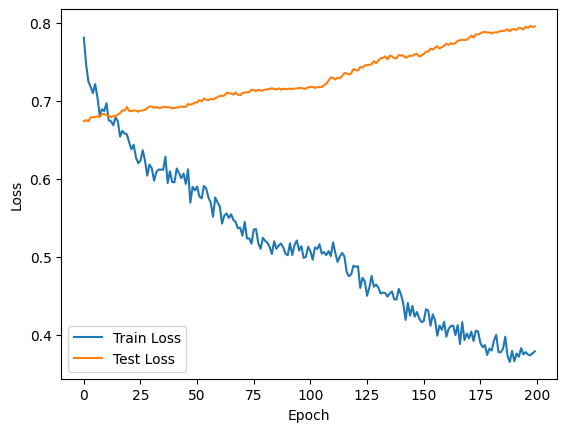

In [27]:
# plot training and test losses
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


# get the r2 score of the dnn model on test set
logits = model(torch.tensor(X_test, dtype=torch.float32)).detach()
# print accuracy and other metricsfrom sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Convert predicted probabilities to binary predictions
y_pred_binary = (logits >= 0)

# Metrics
accuracy = accuracy_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
f1 = f1_score(y_test, y_pred_binary)
roc_auc = roc_auc_score(y_test, y_pred_binary)

print("=" * 40)
print("         Model Evaluation Metrics")
print("=" * 40)
print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Precision:   {precision:.4f}")
print(f"  Recall:      {recall:.4f}")
print(f"  F1 Score:    {f1:.4f}")
print(f"  ROC AUC:     {roc_auc:.4f}")
print("=" * 40)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_binary))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary, target_names=['No Illness', 'Illness']))


         Model Evaluation Metrics
  Accuracy:    0.6015
  Precision:   0.6371
  Recall:      0.7085
  F1 Score:    0.6709
  ROC AUC:     0.5832

Confusion Matrix:
[[ 76  90]
 [ 65 158]]

Classification Report:
              precision    recall  f1-score   support

  No Illness       0.54      0.46      0.50       166
     Illness       0.64      0.71      0.67       223

    accuracy                           0.60       389
   macro avg       0.59      0.58      0.58       389
weighted avg       0.60      0.60      0.60       389



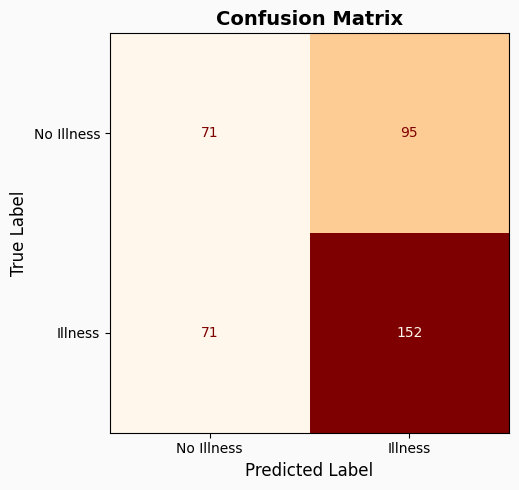

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_binary)

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_facecolor('#f0f0f0')
fig.patch.set_facecolor('#fafafa')

disp = ConfusionMatrixDisplay(cm, display_labels=['No Illness', 'Illness'])
disp.plot(ax=ax, cmap='OrRd', values_format='d', colorbar=False)

ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

In [29]:
# fit logistic regression on train set and predict on test set
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

# Metrics for logistic regression
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)
roc_auc_logreg = roc_auc_score(y_test, y_pred_logreg)

In [30]:
# print the metrics for logistic regression
print("=" * 40)
print("     Logistic Regression Metrics")
print("=" * 40)
print(f"  Accuracy:    {accuracy_logreg:.4f}")
print(f"  Precision:   {precision_logreg:.4f}")
print(f"  Recall:      {recall_logreg:.4f}")
print(f"  F1 Score:    {f1_logreg:.4f}")
print(f"  ROC AUC:     {roc_auc_logreg:.4f}")
print("=" * 40)

     Logistic Regression Metrics
  Accuracy:    0.5707
  Precision:   0.6321
  Recall:      0.6009
  F1 Score:    0.6161
  ROC AUC:     0.5655
